# Data Deduplication

This notebook accompanies the Data Deduplication lecture slides and provides hands-on examples of deduplication techniques, algorithms, and practical implementations.

## Table of Contents

1. [Setup and Dependencies](#setup)
2. [Example Datasets](#datasets)
3. [String Distance Algorithms](#string-distance)
4. [Set-Based and Vector Algorithms](#set-vector)
5. [Phonetic Algorithms](#phonetic)
6. [Practical Deduplication Pipeline](#pipeline)


<a id="setup"></a>
## 1. Setup and Dependencies

Let's start by installing and importing the necessary libraries for our deduplication tasks.

In [ ]:
# Install required packages
!pip install pandas numpy matplotlib seaborn jellyfish python-Levenshtein fuzzywuzzy recordlinkage dedupe phonetics

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jellyfish
import Levenshtein
from fuzzywuzzy import fuzz, process
import recordlinkage
import phonetics
import time
from sklearn.metrics import precision_recall_fscore_support

# Set plot style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 1000)

<a id="datasets"></a>
## 2. Example Datasets

We'll create several example datasets that demonstrate different types of duplication problems.

In [ ]:
# Create a dataset with company name variations
company_data = pd.DataFrame({
    'id': range(1, 11),
    'company_name': [
        'Microsoft Inc.',
        'Microsoft Incorporated',
        'International Business Machines',
        'IBM',
        'Hewlett-Packard',
        'HP',
        'AT&T',
        'AT & T',
        'Walmart',
        'Wal-Mart'
    ],
    'industry': [
        'Technology', 'Technology', 'Technology', 'Technology',
        'Technology', 'Technology', 'Telecommunications', 'Telecommunications',
        'Retail', 'Retail'
    ],
    'revenue_billions': [
        168.1, 168.1, 77.1, 77.1, 58.4, 58.4, 168.9, 168.9, 559.2, 559.2
    ]
})

company_data

,id,company_name,industry,revenue_billions
0,1,Microsoft Inc.,Technology,168.1
1,2,Microsoft Incorporated,Technology,168.1
2,3,International Business Machines,Technology,77.1
3,4,IBM,Technology,77.1
4,5,Hewlett-Packard,Technology,58.4
5,6,HP,Technology,58.4
6,7,AT&T,Telecommunications,168.9
7,8,AT & T,Telecommunications,168.9
8,9,Walmart,Retail,559.2
9,10,Wal-Mart,Retail,559.2


In [ ]:
# Create a dataset with personal name variations
person_data = pd.DataFrame({
    'id': range(1, 13),
    'name': [
        'Jonathan Paul Johnson',
        'Jonathan Johnson',
        'Jon Johnson',
        'J.P. Johnson',
        'Robert Smith',
        'Bob Smith',
        'Catherine Wilson',
        'Katherine Wilson',
        'Kathryn Wilson',
        'Michael Peterson',
        'Mike Peterson',
        'Michael Petersen'
    ],
    'email': [
        'jonathan.johnson@example.com',
        'j.johnson@example.com',
        'jon.johnson@gmail.com',
        'jp.johnson@example.com',
        'robert.smith@example.com',
        'bob.smith@gmail.com',
        'catherine.wilson@example.com',
        'k.wilson@example.com',
        'kathryn.wilson@gmail.com',
        'michael.peterson@example.com',
        'mike.peterson@gmail.com',
        'michael.petersen@example.com'
    ],
    'phone': [
        '+1 (555) 123-4567',
        '555.123.4567',
        '5551234567',
        '1-555-123-4567',
        '+1 (555) 234-5678',
        '555.234.5678',
        '+1 (555) 345-6789',
        '555.345.6789',
        '5553456789',
        '+1 (555) 456-7890',
        '555.456.7890',
        '5554567890'
    ]
})

person_data

,id,name,email,phone
0,1,Jonathan Paul Johnson,jonathan.johnson@example.com,+1 (555) 123-4567
1,2,Jonathan Johnson,j.johnson@example.com,555.123.4567
2,3,Jon Johnson,jon.johnson@gmail.com,5551234567
3,4,J.P. Johnson,jp.johnson@example.com,1-555-123-4567
4,5,Robert Smith,robert.smith@example.com,+1 (555) 234-5678
5,6,Bob Smith,bob.smith@gmail.com,555.234.5678
6,7,Catherine Wilson,catherine.wilson@example.com,+1 (555) 345-6789
7,8,Katherine Wilson,k.wilson@example.com,555.345.6789
8,9,Kathryn Wilson,kathryn.wilson@gmail.com,5553456789
9,10,Michael Peterson,michael.peterson@example.com,+1 (555) 456-7890


In [ ]:
# Create a dataset with address variations
address_data = pd.DataFrame({
    'id': range(1, 9),
    'customer_name': [
        'John Smith',
        'John Smith',
        'Sarah Johnson',
        'Sarah Johnson',
        'Michael Brown',
        'Michael Brown',
        'Emily Davis',
        'Emily Davis'
    ],
    'address': [
        '123 Main St.',
        '123 Main Street',
        '456 Oak Avenue, Apt 1',
        '456 Oak Ave, Unit 1',
        '789 Pine Boulevard',
        '789 Pine Blvd',
        '101 Washington Street, Suite 200',
        '101 Washington St, #200'
    ],
    'city': [
        'New York',
        'New York',
        'Los Angeles',
        'Los Angeles',
        'Chicago',
        'Chicago',
        'San Francisco',
        'San Francisco'
    ],
    'state': [
        'NY',
        'New York',
        'CA',
        'California',
        'IL',
        'Illinois',
        'CA',
        'California'
    ]
})

address_data

,id,customer_name,address,city,state
0,1,John Smith,123 Main St.,New York,NY
1,2,John Smith,123 Main Street,New York,New York
2,3,Sarah Johnson,"456 Oak Avenue, Apt 1",Los Angeles,CA
3,4,Sarah Johnson,"456 Oak Ave, Unit 1",Los Angeles,California
4,5,Michael Brown,789 Pine Boulevard,Chicago,IL
5,6,Michael Brown,789 Pine Blvd,Chicago,Illinois
6,7,Emily Davis,"101 Washington Street, Suite 200",San Francisco,CA
7,8,Emily Davis,"101 Washington St, #200",San Francisco,California


<a id="string-distance"></a>
## 3. String Distance Algorithms

Let's implement and compare different string distance algorithms.

In [ ]:
def compare_string_distances(str1, str2):
    """Compare different string distance metrics between two strings"""

    # Calculate various string distances
    levenshtein_dist = Levenshtein.distance(str1, str2)
    levenshtein_ratio = Levenshtein.ratio(str1, str2)
    jaro_dist = jellyfish.jaro_similarity(str1, str2)
    jaro_winkler_dist = jellyfish.jaro_winkler_similarity(str1, str2)
    fuzz_ratio = fuzz.ratio(str1, str2) / 100
    fuzz_partial_ratio = fuzz.partial_ratio(str1, str2) / 100

    # Create a DataFrame to display results
    results = pd.DataFrame({
        'Algorithm': ['Levenshtein Distance', 'Levenshtein Ratio', 'Jaro similarity',
                     'Jaro-Winkler Similarity', 'Fuzz Ratio', 'Fuzz Partial Ratio'],
        'Score': [levenshtein_dist, levenshtein_ratio, jaro_dist,
                 jaro_winkler_dist, fuzz_ratio, fuzz_partial_ratio],
        'Interpretation': [
            f'{levenshtein_dist} edits needed',
            f'{levenshtein_ratio:.2f} similarity (0-1)',
            f'{jaro_dist:.2f} similarity (0-1)',
            f'{jaro_winkler_dist:.2f} similarity (0-1)',
            f'{fuzz_ratio:.2f} similarity (0-1)',
            f'{fuzz_partial_ratio:.2f} similarity (0-1)'
        ]
    })

    return results

In [ ]:
# Example 1: Company name variations
print("Comparing 'Microsoft Inc.' and 'Microsoft Incorporated'")
compare_string_distances('Microsoft Inc.', 'Microsoft Incorporated')

Comparing 'Microsoft Inc.' and 'Microsoft Incorporated'


,Algorithm,Score,Interpretation
0,Levenshtein Distance,9.000000,9 edits needed
1,Levenshtein Ratio,0.722222,0.72 similarity (0-1)
2,Jaro similarity,0.839827,0.84 similarity (0-1)
3,Jaro-Winkler Similarity,0.903896,0.90 similarity (0-1)
4,Fuzz Ratio,0.720000,0.72 similarity (0-1)
5,Fuzz Partial Ratio,0.930000,0.93 similarity (0-1)


In [ ]:
# Example 2: Name variations
print("Comparing 'Jonathan Paul Johnson' and 'Jon Johnson'")
compare_string_distances('Jonathan Paul Johnson', 'Jon Johnson')

Comparing 'Jonathan Paul Johnson' and 'Jon Johnson'


,Algorithm,Score,Interpretation
0,Levenshtein Distance,10.000000,10 edits needed
1,Levenshtein Ratio,0.687500,0.69 similarity (0-1)
2,Jaro similarity,0.661075,0.66 similarity (0-1)
3,Jaro-Winkler Similarity,0.661075,0.66 similarity (0-1)
4,Fuzz Ratio,0.690000,0.69 similarity (0-1)
5,Fuzz Partial Ratio,0.730000,0.73 similarity (0-1)


In [ ]:
# Example 3: Address variations
print("Comparing '123 Main St.' and '123 Main Street'")
compare_string_distances('123 Main St.', '123 Main Street')

Comparing '123 Main St.' and '123 Main Street'


,Algorithm,Score,Interpretation
0,Levenshtein Distance,4.000000,4 edits needed
1,Levenshtein Ratio,0.814815,0.81 similarity (0-1)
2,Jaro similarity,0.883333,0.88 similarity (0-1)
3,Jaro-Winkler Similarity,0.930000,0.93 similarity (0-1)
4,Fuzz Ratio,0.810000,0.81 similarity (0-1)
5,Fuzz Partial Ratio,0.920000,0.92 similarity (0-1)


In [ ]:
# Example 4: Typo example
print("Comparing 'Microsoft' and 'Microsift' (typo)")
compare_string_distances('Microsoft', 'Microsift')

Comparing 'Microsoft' and 'Microsift' (typo)


,Algorithm,Score,Interpretation
0,Levenshtein Distance,1.000000,1 edits needed
1,Levenshtein Ratio,0.888889,0.89 similarity (0-1)
2,Jaro similarity,0.925926,0.93 similarity (0-1)
3,Jaro-Winkler Similarity,0.955556,0.96 similarity (0-1)
4,Fuzz Ratio,0.890000,0.89 similarity (0-1)
5,Fuzz Partial Ratio,0.890000,0.89 similarity (0-1)


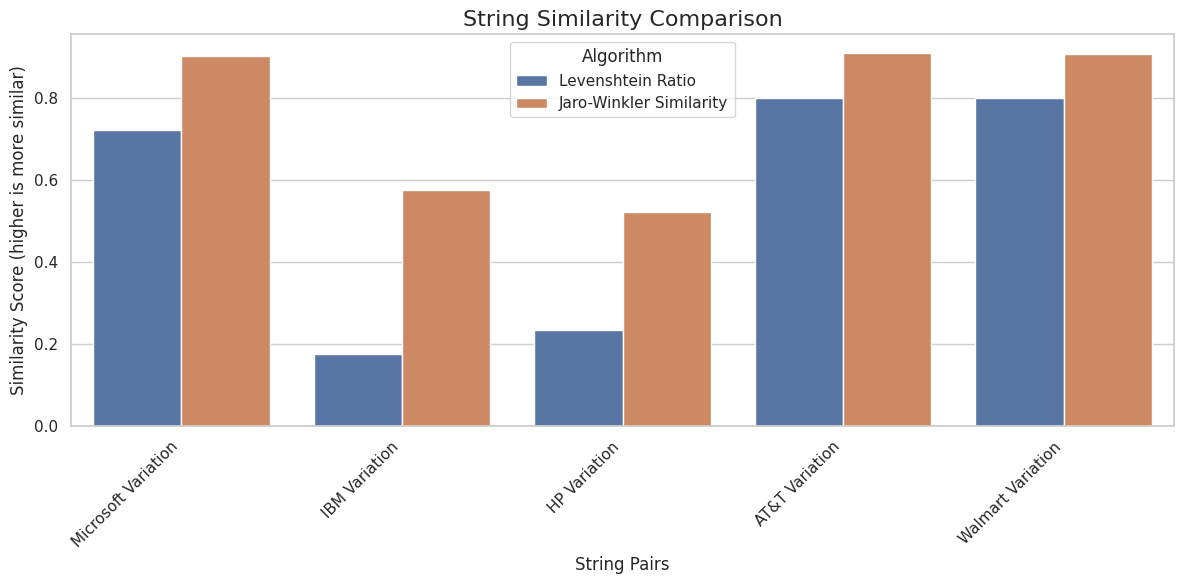

In [ ]:
# Visualize string distance comparison for company names
def plot_string_distances(pairs, algorithms=['Levenshtein Ratio', 'Jaro Distance', 'Jaro-Winkler Similarity']):
    """Plot string distance metrics for multiple string pairs"""

    # Calculate distances for each pair
    results = []
    for name, pair in pairs.items():
        df = compare_string_distances(pair[0], pair[1])
        df = df[df['Algorithm'].isin(algorithms)]
        df['Pair'] = name
        results.append(df)

    # Combine results
    combined = pd.concat(results)

    # Create plot
    plt.figure(figsize=(12, 6))
    chart = sns.barplot(x='Pair', y='Score', hue='Algorithm', data=combined)
    chart.set_title('String Similarity Comparison', fontsize=16)
    chart.set_xlabel('String Pairs', fontsize=12)
    chart.set_ylabel('Similarity Score (higher is more similar)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Define pairs to compare
company_pairs = {
    'Microsoft Variation': ('Microsoft Inc.', 'Microsoft Incorporated'),
    'IBM Variation': ('International Business Machines', 'IBM'),
    'HP Variation': ('Hewlett-Packard', 'HP'),
    'AT&T Variation': ('AT&T', 'AT & T'),
    'Walmart Variation': ('Walmart', 'Wal-Mart')
}

plot_string_distances(company_pairs)

<a id="set-vector"></a>
## 4. Set-Based and Vector Algorithms

Now let's implement and compare set-based and vector-based similarity algorithms.

In [ ]:
def tokenize(text):
    """Convert text to lowercase and split into tokens"""
    return text.lower().split()

def jaccard_similarity(str1, str2):
    """Calculate Jaccard similarity between two strings"""
    set1 = set(tokenize(str1))
    set2 = set(tokenize(str2))

    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))

    return intersection / union if union > 0 else 0


def qgram_similarity(str1, str2, q=2):
    """Calculate q-gram similarity between two strings"""
    # Generate q-grams
    def get_qgrams(text, q):
        text = text.lower()
        return [text[i:i+q] for i in range(len(text)-q+1)]

    qgrams1 = set(get_qgrams(str1, q))
    qgrams2 = set(get_qgrams(str2, q))

    intersection = len(qgrams1.intersection(qgrams2))
    union = len(qgrams1.union(qgrams2))

    return intersection / union if union > 0 else 0

def compare_set_vector_similarities(str1, str2):
    """Compare different set-based and vector-based similarity metrics"""

    # Calculate similarities
    jaccard = jaccard_similarity(str1, str2)
    bigram = qgram_similarity(str1, str2, q=2)
    trigram = qgram_similarity(str1, str2, q=3)

    # Create a DataFrame to display results
    results = pd.DataFrame({
        'Algorithm': ['Jaccard Similarity',  'Bigram Similarity', 'Trigram Similarity'],
        'Score': [jaccard, bigram, trigram],
        'Interpretation': [
            f'{jaccard:.2f} similarity (0-1)',
            f'{bigram:.2f} similarity (0-1)',
            f'{trigram:.2f} similarity (0-1)'
        ]
    })

    return results

In [ ]:
# Example 1: Company name variations
print("Comparing 'International Business Machines' and 'IBM'")
compare_set_vector_similarities('International Business Machines', 'IBM')

Comparing 'International Business Machines' and 'IBM'


,Algorithm,Score,Interpretation
0,Jaccard Similarity,0.0,0.00 similarity (0-1)
1,Bigram Similarity,0.0,0.00 similarity (0-1)
2,Trigram Similarity,0.0,0.00 similarity (0-1)


In [ ]:
# Example 2: Address variations
print("Comparing '456 Oak Avenue, Apt 1' and '456 Oak Ave, Unit 1'")
compare_set_vector_similarities('456 Oak Avenue, Apt 1', '456 Oak Ave, Unit 1')

Comparing '456 Oak Avenue, Apt 1' and '456 Oak Ave, Unit 1'


,Algorithm,Score,Interpretation
0,Jaccard Similarity,0.428571,0.43 similarity (0-1)
1,Bigram Similarity,0.608696,0.61 similarity (0-1)
2,Trigram Similarity,0.440000,0.44 similarity (0-1)


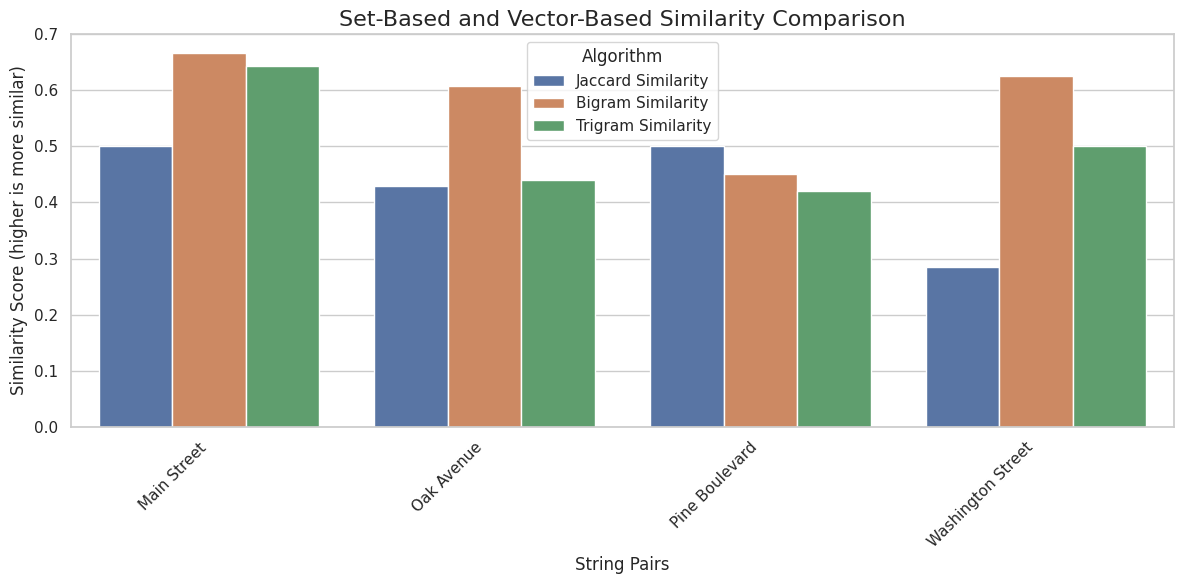

In [ ]:
# Visualize set-based and vector-based similarities
def plot_set_vector_similarities(pairs):
    """Plot set-based and vector-based similarity metrics for multiple string pairs"""

    # Calculate similarities for each pair
    results = []
    for name, pair in pairs.items():
        df = compare_set_vector_similarities(pair[0], pair[1])
        df['Pair'] = name
        results.append(df)

    # Combine results
    combined = pd.concat(results)

    # Create plot
    plt.figure(figsize=(12, 6))
    chart = sns.barplot(x='Pair', y='Score', hue='Algorithm', data=combined)
    chart.set_title('Set-Based and Vector-Based Similarity Comparison', fontsize=16)
    chart.set_xlabel('String Pairs', fontsize=12)
    chart.set_ylabel('Similarity Score (higher is more similar)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Define pairs to compare
address_pairs = {
    'Main Street': ('123 Main St.', '123 Main Street'),
    'Oak Avenue': ('456 Oak Avenue, Apt 1', '456 Oak Ave, Unit 1'),
    'Pine Boulevard': ('789 Pine Boulevard', '789 Pine Blvd'),
    'Washington Street': ('101 Washington Street, Suite 200', '101 Washington St, #200')
}

plot_set_vector_similarities(address_pairs)

<a id="phonetic"></a>
## 5. Phonetic Algorithms

Let's implement and compare phonetic algorithms for name matching.

In [ ]:
def compare_phonetic_encodings(names):
    """Compare different phonetic encodings for a list of names"""

    results = []

    for name in names:
        # Calculate phonetic encodings
        soundex = jellyfish.soundex(name)
        metaphone = jellyfish.metaphone(name)
        nysiis = jellyfish.nysiis(name)
        match_rating = jellyfish.match_rating_codex(name)

        # Add to results
        results.append({
            'Name': name,
            'Soundex': soundex,
            'Metaphone': metaphone,
            'NYSIIS': nysiis,
            'Match Rating': match_rating
        })

    return pd.DataFrame(results)

In [ ]:
# Example 1: Soundex examples from the slides
soundex_examples = [
    'Smith', 'Smythe','Chicken','Chckn','Icecream','Icecrm'
    'Johnson', 'Jonson', 'Johnsen',
    'Catherine', 'Katherine', 'Kathryn',
    'Jackson', 'Jakson',
    'Peterson', 'Petersen'
]

phonetic_results = compare_phonetic_encodings(soundex_examples)
phonetic_results

,Name,Soundex,Metaphone,NYSIIS,Match Rating
0,Smith,S530,SM0,SNAT,SMTH
1,Smythe,S530,SM0,SNYT,SMYTH
2,Johnson,J525,JNSN,JANSAN,JHNSN
3,Jonson,J525,JNSN,JANSAN,JNSN
4,Johnsen,J525,JNSN,JANSAN,JHNSN
5,Catherine,C365,K0RN,CATARAN,CTHRN
6,Katherine,K365,K0RN,CATARAN,KTHRN
7,Kathryn,K365,K0RN,CATRYN,KTHRYN
8,Jackson,J250,JKSN,JACSAN,JCKSN
9,Jakson,J250,JKSN,JACSAN,JKSN


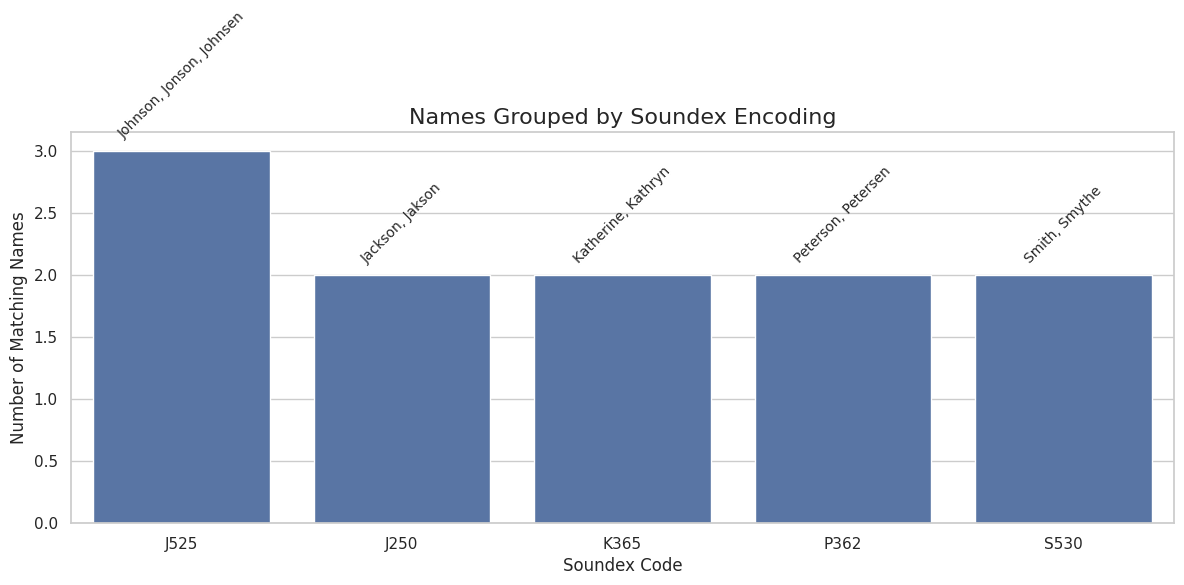

In [ ]:
# Visualize phonetic encoding groups
def plot_phonetic_groups(df, encoding='Soundex'):
    """Plot groups of names with the same phonetic encoding"""

    # Group by the specified encoding
    grouped = df.groupby(encoding)['Name'].apply(list).reset_index()
    grouped['Count'] = grouped['Name'].apply(len)
    grouped = grouped[grouped['Count'] > 1]  # Only show groups with multiple names
    grouped['Names'] = grouped['Name'].apply(lambda x: ', '.join(x))
    grouped = grouped.sort_values('Count', ascending=False)

    # Create plot
    plt.figure(figsize=(12, 6))
    chart = sns.barplot(x=encoding, y='Count', data=grouped)
    chart.set_title(f'Names Grouped by {encoding} Encoding', fontsize=16)
    chart.set_xlabel(f'{encoding} Code', fontsize=12)
    chart.set_ylabel('Number of Matching Names', fontsize=12)

    # Add name labels
    for i, row in enumerate(grouped.itertuples()):
        chart.text(i, row.Count + 0.1, row.Names, ha='center', fontsize=10, rotation=45)

    plt.tight_layout()
    plt.show()

# Plot Soundex groups
plot_phonetic_groups(phonetic_results, 'Soundex')

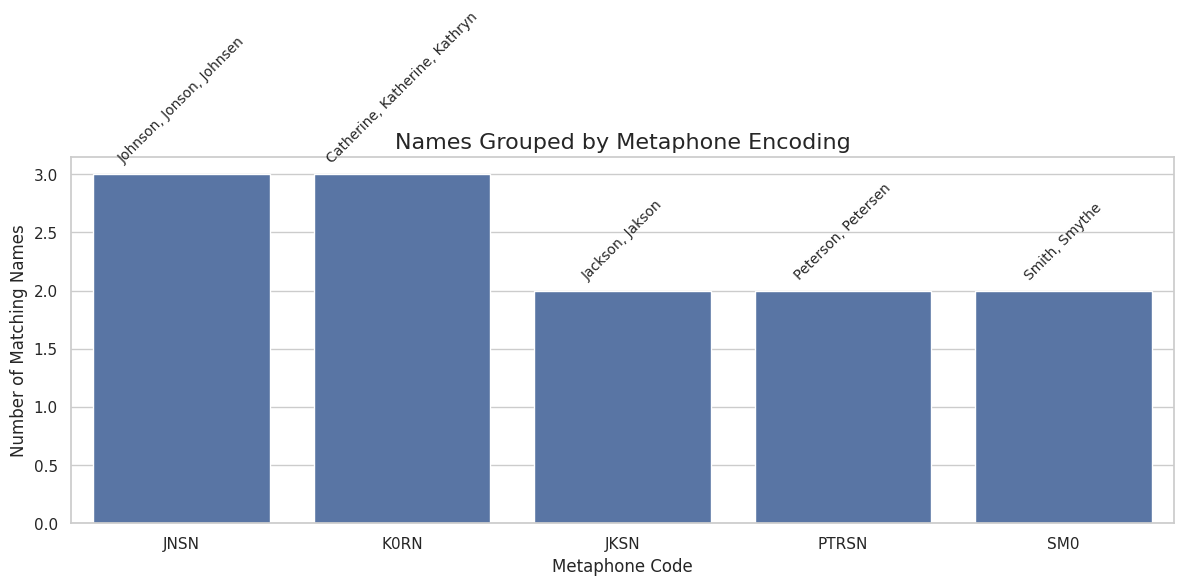

In [ ]:
# Plot Metaphone groups
plot_phonetic_groups(phonetic_results, 'Metaphone')

<a id="pipeline"></a>
## 6. Practical Deduplication Pipeline

Deduplication pipeline using the recordlinkage library.

In [ ]:
# Create a larger dataset with duplicates for demonstration
def create_customer_dataset(size=100, duplicate_rate=0.3):
    """Create a synthetic customer dataset with duplicates"""

    # Base data
    first_names = ['John', 'Michael', 'David', 'Robert', 'James', 'William', 'Richard', 'Thomas',
                  'Mary', 'Jennifer', 'Linda', 'Patricia', 'Elizabeth', 'Susan', 'Jessica', 'Sarah']
    last_names = ['Smith', 'Johnson', 'Williams', 'Jones', 'Brown', 'Davis', 'Miller', 'Wilson',
                 'Moore', 'Taylor', 'Anderson', 'Thomas', 'Jackson', 'White', 'Harris', 'Martin']
    domains = ['gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com', 'aol.com', 'example.com']
    streets = ['Main', 'Oak', 'Maple', 'Washington', 'Park', 'Elm', 'Pine', 'Cedar']
    street_types = ['St', 'Ave', 'Blvd', 'Rd', 'Ln', 'Dr', 'Way', 'Pl']
    cities = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'Philadelphia', 'San Antonio', 'San Diego']
    states = ['NY', 'CA', 'IL', 'TX', 'AZ', 'PA', 'FL', 'OH']

    # Generate base records
    np.random.seed(42)
    base_size = int(size / (1 + duplicate_rate))

    data = []
    for i in range(base_size):
        first_name = np.random.choice(first_names)
        last_name = np.random.choice(last_names)
        email = f"{first_name.lower()}.{last_name.lower()}@{np.random.choice(domains)}"
        street_num = np.random.randint(100, 10000)
        street = np.random.choice(streets)
        street_type = np.random.choice(street_types)
        address = f"{street_num} {street} {street_type}"
        city = np.random.choice(cities)
        state = np.random.choice(states)
        phone = f"{np.random.randint(100, 1000)}-{np.random.randint(100, 1000)}-{np.random.randint(1000, 10000)}"

        data.append({
            'id': i + 1,
            'first_name': first_name,
            'last_name': last_name,
            'email': email,
            'address': address,
            'city': city,
            'state': state,
            'phone': phone
        })

    # Generate duplicates with variations
    duplicate_size = size - base_size
    duplicate_indices = np.random.choice(base_size, duplicate_size, replace=True)

    for i, idx in enumerate(duplicate_indices):
        original = data[idx].copy()
        duplicate = original.copy()
        duplicate['id'] = base_size + i + 1

        # Apply random variations
        variation_type = np.random.choice(['name', 'email', 'address', 'phone'])

        if variation_type == 'name':
            # Name variations
            name_variation = np.random.choice(['nickname', 'typo', 'middle_initial'])
            if name_variation == 'nickname' and duplicate['first_name'] == 'Robert':
                duplicate['first_name'] = 'Bob'
            elif name_variation == 'nickname' and duplicate['first_name'] == 'Michael':
                duplicate['first_name'] = 'Mike'
            elif name_variation == 'typo':
                chars = list(duplicate['last_name'])
                pos = np.random.randint(0, len(chars))
                chars[pos] = chars[pos].lower()
                duplicate['last_name'] = ''.join(chars)
            elif name_variation == 'middle_initial':
                duplicate['first_name'] = f"{duplicate['first_name']} {chr(65 + np.random.randint(0, 26))}"

        elif variation_type == 'email':
            # Email variations
            email_parts = duplicate['email'].split('@')
            if len(email_parts) == 2:
                name_part, domain_part = email_parts
                if '.' in name_part:
                    first, last = name_part.split('.')
                    duplicate['email'] = f"{first[0]}.{last}@{domain_part}"
                else:
                    duplicate['email'] = f"{name_part}_{np.random.randint(1, 100)}@{domain_part}"

        elif variation_type == 'address':
            # Address variations
            address_parts = duplicate['address'].split(' ')
            if len(address_parts) >= 3:
                num, street, type_suffix = address_parts[0], address_parts[1], address_parts[2]
                if type_suffix == 'St':
                    duplicate['address'] = f"{num} {street} Street"
                elif type_suffix == 'Ave':
                    duplicate['address'] = f"{num} {street} Avenue"
                elif type_suffix == 'Blvd':
                    duplicate['address'] = f"{num} {street} Boulevard"
                else:
                    duplicate['address'] = f"{num} {street} {type_suffix}."

        elif variation_type == 'phone':
            # Phone variations
            phone_parts = duplicate['phone'].split('-')
            if len(phone_parts) == 3:
                area, prefix, number = phone_parts
                format_type = np.random.choice(['dots', 'parens', 'spaces'])
                if format_type == 'dots':
                    duplicate['phone'] = f"{area}.{prefix}.{number}"
                elif format_type == 'parens':
                    duplicate['phone'] = f"({area}) {prefix}-{number}"
                elif format_type == 'spaces':
                    duplicate['phone'] = f"{area} {prefix} {number}"

        data.append(duplicate)

    # Create DataFrame and shuffle
    df = pd.DataFrame(data)
    return df.sample(frac=1).reset_index(drop=True)

# Create dataset
customer_data = create_customer_dataset(size=100, duplicate_rate=0.3)
customer_data.head(10)

,id,first_name,last_name,email,address,city,state,phone
0,28,Mary,Smith,mary.smith@yahoo.com,4836 Maple Rd,New York,NY,250-514-5061
1,71,Elizabeth,Jones,elizabeth.jones@outlook.com,3241 Washington Way,Chicago,AZ,975-281-5186
2,64,William,Jackson,william.jackson@hotmail.com,7286 Main Rd,Houston,AZ,332-175-5360
3,35,John,Martin,john.martin@gmail.com,4655 Maple Blvd,Philadelphia,FL,121-849-2693
4,67,Mary,Miller,mary.miller@aol.com,7960 Oak Ave,San Antonio,PA,322-733-8330
5,82,Jennifer,Taylor,jennifer.taylor@hotmail.com,4368 Park Ave,Houston,PA,157-759-7619
6,19,Robert,White,robert.white@example.com,5550 Cedar Ave,San Antonio,TX,572-330-8392
7,63,Richard,Jackson,richard.jackson@gmail.com,3014 Main Dr,New York,NY,161-695-1728
8,8,Michael,White,michael.white@example.com,3943 Elm Ln,San Antonio,CA,829-655-1161
9,97,Elizabeth,harris,elizabeth.harris@hotmail.com,4736 Washington Ln,San Diego,FL,798-342-4157


In [ ]:
# Step 1: Data Standardization
def standardize_data(df):
    """Standardize data for deduplication"""

    # Create a copy to avoid modifying the original
    df_std = df.copy()

    # Standardize names
    df_std['first_name'] = df_std['first_name'].str.lower().str.strip()
    df_std['last_name'] = df_std['last_name'].str.lower().str.strip()

    # Extract email domain
    df_std['email_domain'] = df_std['email'].str.split('@').str[1]

    # Standardize addresses
    df_std['address'] = df_std['address'].str.lower().str.strip()
    df_std['address'] = df_std['address'].str.replace('street', 'st', regex=False)
    df_std['address'] = df_std['address'].str.replace('avenue', 'ave', regex=False)
    df_std['address'] = df_std['address'].str.replace('boulevard', 'blvd', regex=False)
    df_std['address'] = df_std['address'].str.replace('.', '', regex=False)

    # Standardize phone numbers
    df_std['phone_std'] = df_std['phone'].str.replace('-', '')
    df_std['phone_std'] = df_std['phone_std'].str.replace('.', '')
    df_std['phone_std'] = df_std['phone_std'].str.replace(' ', '')
    df_std['phone_std'] = df_std['phone_std'].str.replace('(', '')
    df_std['phone_std'] = df_std['phone_std'].str.replace(')', '')

    return df_std

# Standardize the customer data
customer_data_std = standardize_data(customer_data)
customer_data_std.head()

,id,first_name,last_name,email,address,city,state,phone,email_domain,phone_std
0,28,mary,smith,mary.smith@yahoo.com,4836 maple rd,New York,NY,250-514-5061,yahoo.com,2505145061
1,71,elizabeth,jones,elizabeth.jones@outlook.com,3241 washington way,Chicago,AZ,975-281-5186,outlook.com,9752815186
2,64,william,jackson,william.jackson@hotmail.com,7286 main rd,Houston,AZ,332-175-5360,hotmail.com,3321755360
3,35,john,martin,john.martin@gmail.com,4655 maple blvd,Philadelphia,FL,121-849-2693,gmail.com,1218492693
4,67,mary,miller,mary.miller@aol.com,7960 oak ave,San Antonio,PA,322-733-8330,aol.com,3227338330


In [ ]:
# Step 2: Blocking - Reduce comparison space
def create_blocks(df):
    """Create blocks for efficient comparison"""

    # Initialize the indexer
    indexer = recordlinkage.Index()

    # Block on last name (exact match required)
    indexer.block('last_name')

    # Generate pairs
    pairs = indexer.index(df)

    print(f"Number of record pairs to compare: {len(pairs)}")
    print(f"Reduction from full comparison: {1 - len(pairs) / (len(df) * (len(df) - 1) / 2):.2%}")

    return pairs

# Create blocks
pairs = create_blocks(customer_data_std)

Number of record pairs to compare: 347
Reduction from full comparison: 92.99%


In [ ]:
# Step 3: Record Comparison
def compare_records(df, pairs):
    """Compare records using multiple comparison methods"""

    # Initialize the comparison object
    compare = recordlinkage.Compare()

    # Add comparison methods
    compare.string('first_name', 'first_name', method='jarowinkler', label='first_name')
    compare.string('last_name', 'last_name', method='jarowinkler', label='last_name')
    compare.string('email', 'email', method='jarowinkler', label='email')
    compare.string('address', 'address', method='jarowinkler', label='address')
    compare.string('city', 'city', method='jarowinkler', label='city')
    compare.exact('state', 'state', label='state')
    compare.string('phone_std', 'phone_std', method='jarowinkler', label='phone')

    # Compute comparison vectors
    features = compare.compute(pairs, df)

    return features

# Compare records
features = compare_records(customer_data_std, pairs)
features.head()

first_name  last_name     email   address      city  state     phone
7  2    0.523810        1.0  0.698428  0.736111  0.422619      0  0.422222
8  6    0.436508        1.0  0.762836  0.495671  1.000000      0  0.300000
12 6    0.527778        1.0  0.656517  0.524603  0.477273      0  0.533333
   8    0.511905        1.0  0.636752  0.557071  0.477273      0  0.533333
13 2    0.523810        1.0  0.846240  0.555556  1.000000      0  0.657143

In [ ]:
# Step 4: Classification
def classify_matches(features, threshold=0.85):
    """Classify record pairs as matches or non-matches"""

    # Calculate mean similarity across all features
    features['mean_sim'] = features.mean(axis=1)

    # Classify based on threshold
    matches = features[features['mean_sim'] >= threshold]

    print(f"Number of matches found: {len(matches)}")

    return matches

# Classify matches
matches = classify_matches(features)
matches.head()

Number of matches found: 26


,,first_name,last_name,email,address,city,state,phone,mean_sim
30,24,1.000000,1.0,1.000000,1.0,1.0,1,1.0,1.000000
35,29,1.000000,1.0,0.854622,1.0,1.0,1,1.0,0.979232
36,20,1.000000,1.0,1.000000,1.0,1.0,1,1.0,1.000000
40,39,1.000000,1.0,1.000000,1.0,1.0,1,1.0,1.000000
46,8,0.780952,1.0,1.000000,1.0,1.0,1,1.0,0.968707


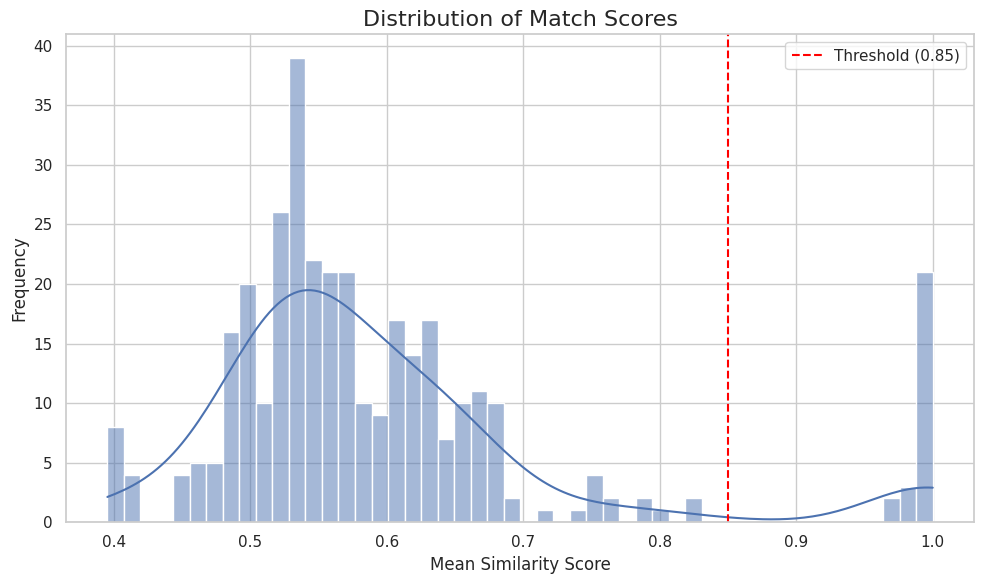

In [ ]:
# Step 5: Evaluate and Visualize Results
def visualize_match_distribution(features):
    """Visualize the distribution of match scores"""

    # Calculate mean similarity
    features['mean_sim'] = features.mean(axis=1)

    # Create histogram
    plt.figure(figsize=(10, 6))
    sns.histplot(features['mean_sim'], bins=50, kde=True)
    plt.axvline(x=0.85, color='red', linestyle='--', label='Threshold (0.85)')
    plt.title('Distribution of Match Scores', fontsize=16)
    plt.xlabel('Mean Similarity Score', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Visualize match distribution
visualize_match_distribution(features)

In [ ]:
# Step 6: Examine Matches
def examine_matches(df, matches):
    """Examine the matched record pairs"""

    # Get the indices of matches
    match_indices = matches.index.tolist()

    # Create a list to store match pairs
    match_pairs = []

    # Extract the original records for each match pair
    for idx1, idx2 in match_indices:
        record1 = df.loc[idx1]
        record2 = df.loc[idx2]
        similarity = matches.loc[(idx1, idx2), 'mean_sim']

        match_pairs.append({
            'id1': record1['id'],
            'id2': record2['id'],
            'name1': f"{record1['first_name']} {record1['last_name']}",
            'name2': f"{record2['first_name']} {record2['last_name']}",
            'email1': record1['email'],
            'email2': record2['email'],
            'address1': record1['address'],
            'address2': record2['address'],
            'phone1': record1['phone'],
            'phone2': record2['phone'],
            'similarity': similarity
        })

    # Create DataFrame
    match_df = pd.DataFrame(match_pairs)

    return match_df

# Examine matches
match_results = examine_matches(customer_data, matches)
match_results.head(10)

,id1,id2,name1,name2,email1,email2,address1,address2,phone1,phone2,similarity
0,29,100,Jennifer Williams,Jennifer Williams,jennifer.williams@outlook.com,jennifer.williams@outlook.com,6387 Oak Pl,6387 Oak Pl,671-980-3049,671-980-3049,1.000000
1,24,84,Sarah Smith,Sarah Smith,sarah.smith@gmail.com,s.smith@gmail.com,5349 Park Rd,5349 Park Rd,809-515-5931,809-515-5931,0.979232
2,33,99,Mary Jackson,Mary Jackson,mary.jackson@yahoo.com,mary.jackson@yahoo.com,5073 Oak Ave,5073 Oak Avenue,819-780-9352,819-780-9352,1.000000
3,60,90,Richard Jones,Richard jones,richard.jones@yahoo.com,richard.jones@yahoo.com,7768 Oak Ln,7768 Oak Ln,475-519-1728,475-519-1728,1.000000
4,86,8,Mike White,Michael White,michael.white@example.com,michael.white@example.com,3943 Elm Ln,3943 Elm Ln,829-655-1161,829-655-1161,0.968707
5,89,58,Linda Thomas,Linda Thomas,l.thomas@aol.com,linda.thomas@aol.com,4207 Pine Dr,4207 Pine Dr,598-853-3082,598-853-3082,0.980714
6,85,28,Mary Smith,Mary Smith,mary.smith@yahoo.com,mary.smith@yahoo.com,4836 Maple Rd.,4836 Maple Rd,250-514-5061,250-514-5061,1.000000
7,94,64,William Jackson,William Jackson,william.jackson@hotmail.com,william.jackson@hotmail.com,7286 Main Rd.,7286 Main Rd,332-175-5360,332-175-5360,1.000000
8,96,63,Richard Jackson,Richard Jackson,richard.jackson@gmail.com,richard.jackson@gmail.com,3014 Main Dr,3014 Main Dr,161-695-1728,161-695-1728,1.000000
9,12,79,David Smith,David Smith,david.smith@hotmail.com,david.smith@hotmail.com,5992 Oak Way,5992 Oak Way.,127-234-9392,127-234-9392,1.000000


In [ ]:
# Step 7: Create Master Records
def create_master_records(df, match_results):
    """Create master records by consolidating duplicates"""

    # Create a copy of the original data
    master_df = df.copy()

    # Create a mapping of duplicate IDs to master IDs
    id_mapping = {}

    # Process each match pair
    for _, row in match_results.iterrows():
        id1 = row['id1']
        id2 = row['id2']

        # Always use the smaller ID as the master ID
        master_id = min(id1, id2)
        duplicate_id = max(id1, id2)

        # Update the mapping
        id_mapping[duplicate_id] = master_id

    # Create a set of duplicate IDs to remove
    duplicate_ids = set(id_mapping.keys())

    # Filter out duplicates
    master_df = master_df[~master_df['id'].isin(duplicate_ids)].copy()

    # Add a column to indicate master records
    master_df['is_master'] = True
    master_df['duplicate_count'] = 0

    # Count duplicates for each master record
    for duplicate_id, master_id in id_mapping.items():
        if master_id in master_df['id'].values:
            master_df.loc[master_df['id'] == master_id, 'duplicate_count'] += 1

    return master_df

# Create master records
master_records = create_master_records(customer_data, match_results)
master_records.head()

,id,first_name,last_name,email,address,city,state,phone,is_master,duplicate_count
0,28,Mary,Smith,mary.smith@yahoo.com,4836 Maple Rd,New York,NY,250-514-5061,True,1
1,71,Elizabeth,Jones,elizabeth.jones@outlook.com,3241 Washington Way,Chicago,AZ,975-281-5186,True,0
2,64,William,Jackson,william.jackson@hotmail.com,7286 Main Rd,Houston,AZ,332-175-5360,True,1
3,35,John,Martin,john.martin@gmail.com,4655 Maple Blvd,Philadelphia,FL,121-849-2693,True,0
4,67,Mary,Miller,mary.miller@aol.com,7960 Oak Ave,San Antonio,PA,322-733-8330,True,0


Original record count: 100
Master record count: 76
Duplicate record count: 24
Duplicate rate: 24.00%


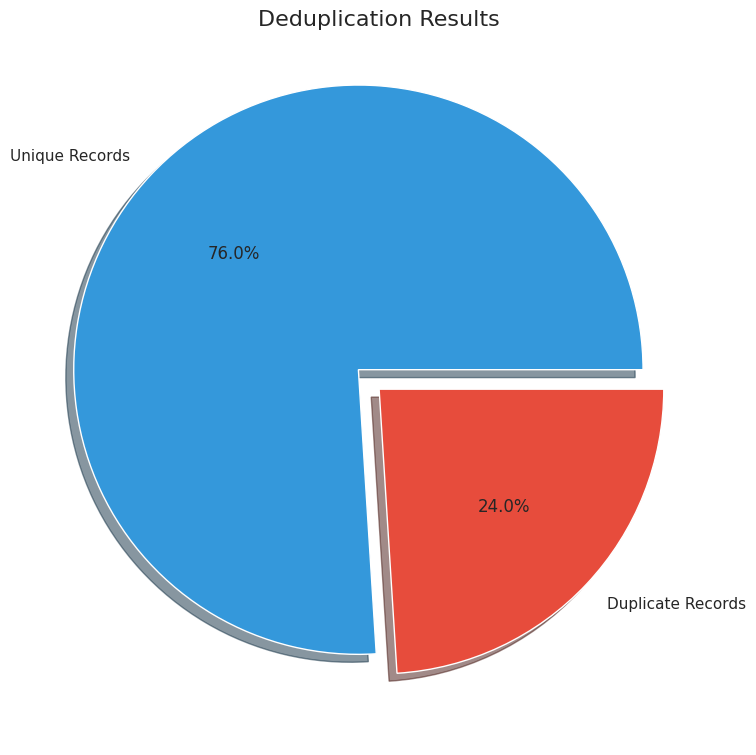

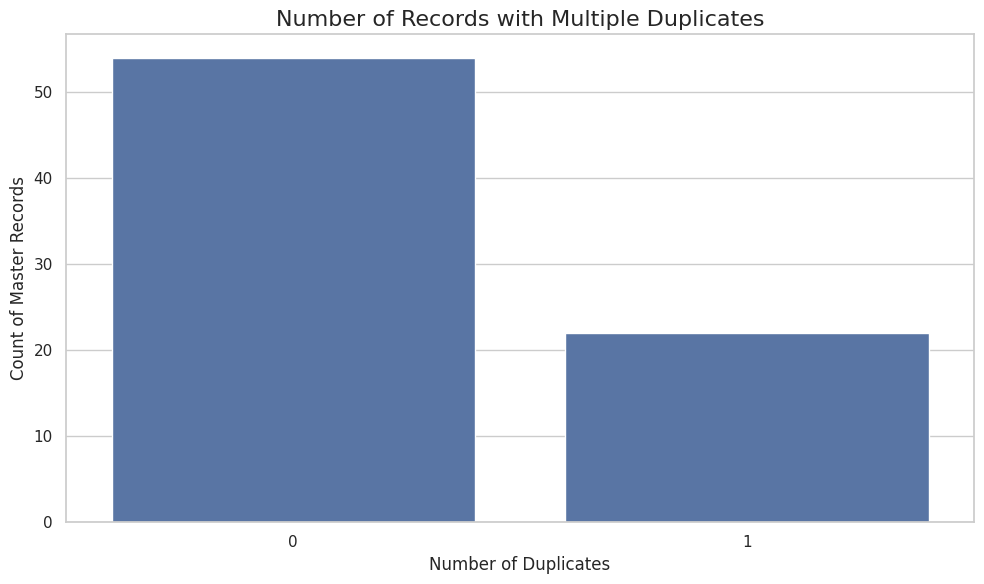

In [ ]:
# Step 8: Summarize Results
def summarize_deduplication(original_df, master_df):
    """Summarize the deduplication results"""

    original_count = len(original_df)
    master_count = len(master_df)
    duplicate_count = original_count - master_count
    duplicate_rate = duplicate_count / original_count

    print(f"Original record count: {original_count}")
    print(f"Master record count: {master_count}")
    print(f"Duplicate record count: {duplicate_count}")
    print(f"Duplicate rate: {duplicate_rate:.2%}")

    # Create a pie chart
    plt.figure(figsize=(8, 8))
    plt.pie([master_count, duplicate_count],
            labels=['Unique Records', 'Duplicate Records'],
            autopct='%1.1f%%',
            colors=['#3498DB', '#E74C3C'],
            explode=(0.1, 0),
            shadow=True)
    plt.title('Deduplication Results', fontsize=16)
    plt.tight_layout()
    plt.show()

    # Show duplicate counts
    duplicate_counts = master_df['duplicate_count'].value_counts().sort_index()

    plt.figure(figsize=(10, 6))
    sns.barplot(x=duplicate_counts.index, y=duplicate_counts.values)
    plt.title('Number of Records with Multiple Duplicates', fontsize=16)
    plt.xlabel('Number of Duplicates', fontsize=12)
    plt.ylabel('Count of Master Records', fontsize=12)
    plt.tight_layout()
    plt.show()

# Summarize results
summarize_deduplication(customer_data, master_records)